

# Part 2. Lifetime exposure

Functions from dem4cli for:

- GMT mapping : this is done year-to-year by matching smoothed GMT timeseries of your original simulation with target stylized GMT timeseries
- Land fraction exposed / average exceedances per year: Note - If your data is binary you will get the annual fraction of land exposed, but if it is not binary you will get the area-weighted average number of exceedances
- Lifetime exposure : per region/country, birthyear and GMT stylized pathways

To do / issues:
- add example smoothing da
- add back 'raw' RCP in le and lfe output if you pick to smooth the data? 
- region_names if subnational make them a bit more helpful! latin names not the acronyms

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import pickle as pk
from scipy import interpolate
import regionmask
import glob, os, re, sys
import openpyxl
import matplotlib.pyplot as plt
import warnings
from math import ceil 
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 20)
%matplotlib inline 

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sys.path.append('../..') # location of dem4cli package
#import demographics4climate as dem4cli # to call them as dem4cli.function 
from dem4cli import * # to call fxns directly


In [3]:
flags

{'version': 2,
 'pop_resolution': 0.1,
 'GMT_mapping': 'year_to_year',
 'cohort_sizes_source': 'UNWPP2024',
 'countrymask': 'shapefile'}

In [4]:
bbox_europe = [ 31.99,  71.09, -14.96,  34.94]
bbox_indiaws = [ 2.00, 35.00, 66.00, 100.00 ]

## 0) Population preprocessing

See part 1 for more details: load and preprocess all demographic data (population, cohort sizes, life expectancy)

In [5]:
d_countries = preprocess_all_country_data(

    filepath_lifeexpectancy = filepath_lifeexpectancy, # life expectancy data
    start_birthyear=1950,
    end_birthyear=2025,                 # endyear is taken from end_birthyear + max life expectancy

    dir_cohortsizes = dir_cohortsizes,  # cohort size data
    data_source_cohorts='UNWPP2024',
    extend_method='linear',             # note, 'slinear' not implemented for UNWPP2024
    by_sex=False,                       # NOTE by_sex not implemented
                                            
    dir_population= dir_population,     # gridded pop data 
    ssp=2,
    urbanrural=False,                   # NOTE urbanrural not implemented for v2
    #bbox = bbox_europe,                        # could use bbox europe!!
    bbox = bbox_indiaws,

    filepath_countrymask = filepath_countrymask,    # country masks 
    data_source_countrymask = 'shapefile',
    fillcoast=False, 
    fix_smallislands=False,
    
    filepath_world_bank = filepath_world_bank_meta, # metadata 
    filepath_lookuptable = filepath_lookuptable,    # country filtering
    filter_countries=True,
    worldbank_filter=True, 
    )

    
df_countries = d_countries['info_pop']
gdf_country_borders = d_countries['borders'] 
da_regions = df_countries['region'].unique()
da_population = d_countries['population_map']
df_birthyears = d_countries['birth_years'] # NA
df_life_expectancy_5 = d_countries['life_expectancy_5']
da_cohort_size = d_countries['cohort_size']
countries_regions, countries_mask = d_countries['mask'] 

load_country_metadata took 0.08 s
load_unwpp_lifeexpectancy took 22.84 s
get_life_expectancies took 0.00 s
loading cohort sizes from UNWPP2024
load_cohort_sizes took 29.72 s
interpolate_cohortsize_countries took 0.01 s
opening compass - historical
opening compass - ssp2
load_population took 2.31 s
load_countrymask took 4.07 s
preprocess_all_country_data took 59.08 s


In [6]:
da_life_expectancy = (
    df_life_expectancy_5
    .to_xarray()
    .to_array('country')
    .rename({'Year': 'birth_year'})
    .astype(float)
)

In [7]:
df_life_expectancy_5

Country,Afghanistan,Bangladesh,Bhutan,China,India,Indonesia,Malaysia,Maldives,Myanmar,Nepal,Pakistan,Sri Lanka,Thailand
Year,,,,,,,,,,,,,
1950,54.7051,64.3785,57.9877,63.3719,64.9698,64.4966,66.4392,63.9401,62.6148,62.5044,62.6678,70.9775,64.0547
1951,54.9914,64.5367,58.0507,63.7418,65.1229,64.8597,66.9031,63.8358,62.9,62.4709,63.1308,71.3957,64.265
1952,55.3287,65.1587,58.1325,64.1075,65.192,65.2115,67.3864,63.7576,63.2916,62.495,63.5415,71.7427,64.4666
1953,55.6465,65.3259,58.2343,64.3401,65.3613,65.232,67.9438,63.7143,63.649,62.5481,63.9462,72.1706,64.6241
1954,55.9651,65.6375,58.3607,59.6083,65.6637,65.7349,68.507,63.6957,63.8958,62.719,64.333,72.5638,64.9301
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,76.3344,82.9225,81.2563,85.5551,80.6474,78.9437,83.6094,88.1359,76.2366,78.775,78.0595,84.4865,83.8029
2022,76.441,83.1252,81.4446,85.748,80.8202,79.0574,83.7631,88.3445,76.3769,78.9434,78.1174,84.6453,83.9901
2023,76.5566,83.3198,81.6378,85.9295,80.9699,79.1701,83.9184,88.5411,76.5151,79.1097,78.1822,84.8139,84.1884


## 1) Load GMT stylized trajs

Load stylized GMT trajectories to emulate with the GMT-remapping. 

Using the options : 
- extension past 2100  with 10yrtrend (also available: 10yrmean, lastyear)
- Smoothing of first decades (OS and noOS currently not smoothed). Also available: no smoothing



In [ ]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
    smooth_first_decades=True
)

load_GMT took 8.74 s


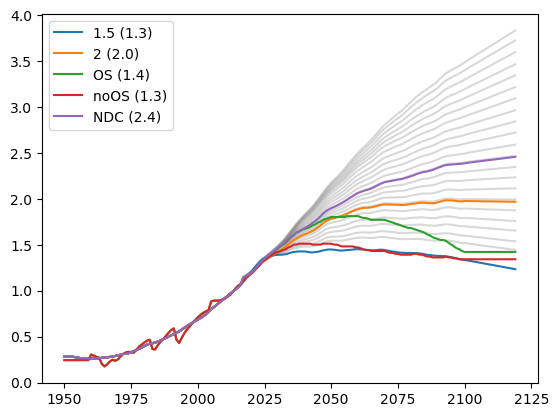

In [54]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

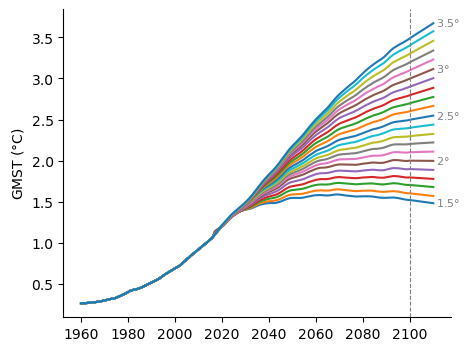

In [56]:
warminglevels = [1.5, 2, 2.5, 3, 3.5]
offsets = [-.01, 0, +.05, +.12, +.18]

fig, ax = plt.subplots(figsize=(5,4))

df_GMT_strj.loc[1960:2110].plot(ax=ax, legend=False)

ax.axvline(2100, ls='--', c='gray', lw=.8)
for lev, off in zip(warminglevels, offsets):
    ax.text(2111, lev+off, str(lev)+'$\degree$', c='gray', fontsize='8', va='center')

plt.ylabel('GMST ($\degree$C)')

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

## 2) Load climate data and GMT-mapping recipe

Equivalent of old load_isimip() function. Loads in metadata with remapping recipe based on each target trajectory, linked to each original simulation

You can account for re-baselining GMTs to a different baseline (e.g. a bias-adjustment period)



In [57]:
gmt_anomaly_correction = calc_gmt_anomaly_correction(
    filepath_gmst_obs=os.path.join(data_dir, 'gmst-obs/GCH_time_series_of_annual_global_temperatures_1850-2024_wrt_1991-2020.csv'),
    col='ERA5',
    gmt_anomaly_baseline_period=(1985,2014),)

gmt_anomaly_correction

# since the climate data is bias-adjusted to 1985-2014 rebaseline everything to this 

0.7432

In [ ]:
# We will run the load_climate_data function with these arguments:

GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']
extremes="heatwavedarea" # e.g. "FWI95d"
model_names = GCMs
filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv')
year_start=1950
year_end = 2119
gmt_anomaly_baseline_period = (1985,2014)
gmt_anomaly_correction = 0.74
rolling_window=21
min_periods=11
max_diff_valid=.2

In [61]:
d_climate_data_meta = load_climate_data(
    extremes = "heatwavedarea",                   # e.g. "FWI95d"
    model_names = GCMs,                # GCMs : test just for two GCMs
    df_GMT_strj = df_GMT_strj ,                # stylized trajectories
    GMT_extra_trajectories = None,
    filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv'),
    scenarios = scenarios,
    rolling_window=21,
    min_periods=11,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = 0.74,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .2, 
    )

Processing climate data
Processing for heatwavedarea


In [63]:
print(d_climate_data_meta.keys())

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])


In [ ]:
df_mapping = pd.DataFrame(data=d_climate_data_meta[1]['ind_RCP2GMT_strj'], columns=df_GMT_strj.columns, index=np.arange(1950,2120) )
df_mapping

# what index of the simulation is mapped, for all GMT levels, to each year in the scenario-GCM combination corresponding to the first dictionary entry

,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3,2.4,...,2.6,2.7,2.8,2.9,3.0,3.1,3.2,3.3,3.4,3.5
1950,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
1951,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
1952,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
1953,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
1954,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,69,72,75,78,81,84,87,91,95,100,...,130,149,149,149,149,149,149,149,149,149
2116,69,72,75,78,81,84,87,92,95,100,...,131,149,149,149,149,149,149,149,149,149
2117,69,72,75,78,81,84,87,92,95,100,...,132,149,149,149,149,149,149,149,149,149
2118,69,71,75,78,81,84,87,92,95,100,...,133,149,149,149,149,149,149,149,149,149


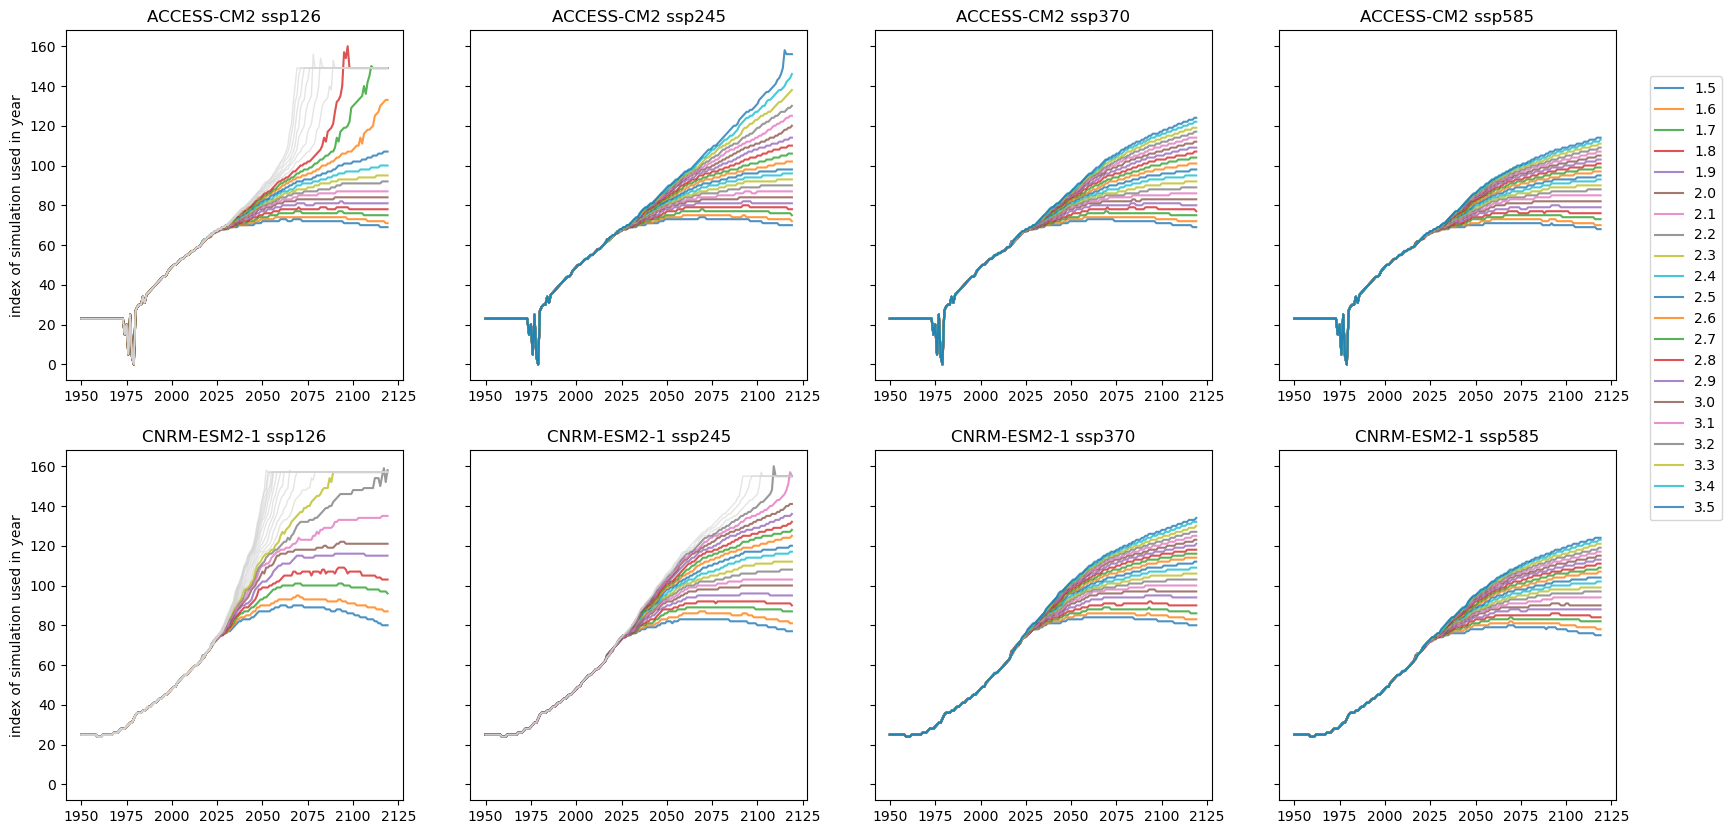

In [65]:
fig, axes = plt.subplots(2,4,figsize=(20,10),sharey=True)

axes=axes.flatten()

for i, ax in enumerate(axes):

    i+=1

    df_mapping = pd.DataFrame(data =d_climate_data_meta[i]['ind_RCP2GMT_strj'], columns=df_GMT_strj.columns, index=np.arange(1950,2120) )
    valid = np.array(d_climate_data_meta[i]['GMT_strj_valid'])  # your 0/1 array

    for col, is_valid in zip(df_mapping.columns, valid):
        if is_valid:
            ax.plot(df_mapping.index, df_mapping[col], lw=1.5, alpha=0.8,label=col)
        else:
            ax.plot(df_mapping.index, df_mapping[col], color='lightgray', lw=1.0, alpha=0.6)


    ax.set_title(d_climate_data_meta[i]['model']+' '+d_climate_data_meta[i]['scenario'])

    if i==1 or i==5:
        ax.set_ylabel('index of simulation used in year')
    
    if i==4:
        ax.legend(loc=(1.1,-.4))

    # visualize the remapping

    # gray = not valid 

## 3) Land fraction exposed

Note! If your data is BINARY this is land fraction exposed. 

If your data is not binary but is N OF EXCEEDANCES PER YEAR, then you will get the area-weighted average n of exceedances per spatial unit

In [66]:
for i in list(d_climate_data_meta.keys()):
    scenario = d_climate_data_meta[i]['scenario']
    model = d_climate_data_meta[i]['model']
    print(i, model, scenario)

# get the names / experiments of each element of the dict

# for each dict entry you have remapping recipe for each valid target trajectory 

1 ACCESS-CM2 ssp126
2 ACCESS-CM2 ssp245
3 ACCESS-CM2 ssp370
4 ACCESS-CM2 ssp585
5 CNRM-ESM2-1 ssp126
6 CNRM-ESM2-1 ssp245
7 CNRM-ESM2-1 ssp370
8 CNRM-ESM2-1 ssp585
9 CanESM5 ssp126
10 CanESM5 ssp245
11 CanESM5 ssp370
12 CanESM5 ssp585
13 EC-EARTH ssp126
14 EC-EARTH ssp245
15 EC-EARTH ssp370
16 EC-EARTH ssp585
17 MPI-ESM1-2-HR ssp126
18 MPI-ESM1-2-HR ssp245
19 MPI-ESM1-2-HR ssp370
20 MPI-ESM1-2-HR ssp585
21 MRI-ESM2-0 ssp126
22 MRI-ESM2-0 ssp245
23 MRI-ESM2-0 ssp370
24 MRI-ESM2-0 ssp585


In [67]:
subset = dict(list(d_climate_data_meta.items())[0:2])

# test just for a subset of the simulations (faster to run)

In [ ]:
#GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
#scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']
GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS']
#climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI'.  # structure should be : climatedata_dir/scenario/model/'*{model}*{extreme}.nc
climatedata_dir = '/data/brussel/vo/000/bvo00012/vsc11137/source2suffering/data/isimip/isimip2b/heatwavedarea/hwmid99'

ds_lfe_perregion_perrun, ds_lfe_percountry_perrun, region_names = calc_landfraction_exposed(
    subset, # replace with d_climate_data_meta to run all data
    df_countries, 
    countries_regions, 
    countries_mask, 
    climatedata_dir,
    GMT_labels = df_GMT_strj.columns,
    GMT_extra_trajectories_names = GMT_extra_trajectories_names,
    year_start=1950,
    year_end=2119,
    bbox=bbox_europe,
    weights=None,
    areaweighted=True,
    convert_to_binary=False,            # if your data array is number of exceedances per year (not binary) you will get area-weighted average number of exceedances by default
                                        # if you set this to True your data is turned binary and you can get fraction of land area exposed to at least 1 day
    convert_to_binary_threshold=0,      # here you can change the threshold to e.g. get the fraction of land area exposed to at least X days 
    smoothing_window=21                 # window to smooth also the impact data, get only forced signal not internal variability
                                        # turn this to None for default configuration
)


# note: calling this LFE can be misleading if your data is not binary!

                         🟠 Remapping Simulation 1 of 2 🟠

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
load_climate_data_array took 0.13 s
Computing land fraction exposed (LFE) for RCP 

Computing land fraction exposed (LFE) for 15                                

Computing land fraction exposed (LFE) for 20                                

Computing land fraction exposed (LFE) for NDC                               

Computing land fraction exposed (LFE) for OS                                

Computing land fraction exposed (LFE) for noOS                              

Computing land fraction exposed (LFE) for strj                              

                         🟠 Remapping Simulation 2 of 2 🟠      

In [41]:
rename_dict = {
    i: f"{subset[i]['model']} {subset[i]['scenario']}"
    for i in subset.keys()
}
rename_dict


# for plotting 

{1: 'ACCESS-CM2 ssp126', 2: 'ACCESS-CM2 ssp245'}

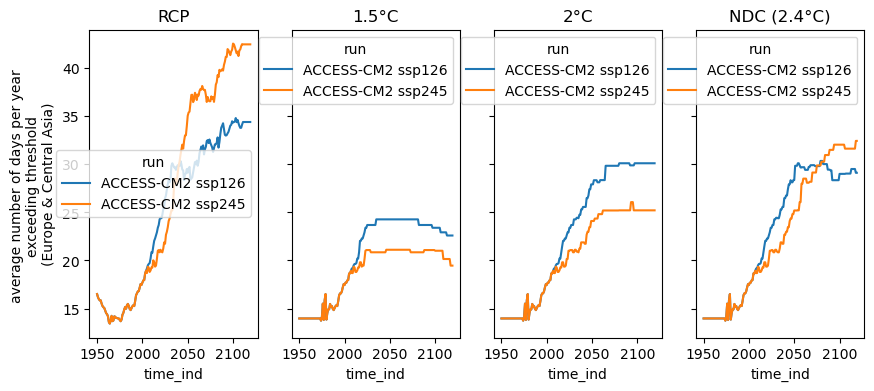

In [ ]:

fig, axes = plt.subplots(1,4,sharey=True,figsize=(10,4))

ds_lfe_perregion_perrun.sel(region=0)['landfrac_peryear_perregion_RCP'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[0])
ds_lfe_perregion_perrun.sel(region=0)['landfrac_peryear_perregion_15'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[1])
ds_lfe_perregion_perrun.sel(region=0)['landfrac_peryear_perregion_20'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[2])
ds_lfe_perregion_perrun.sel(region=0)['landfrac_peryear_perregion_NDC'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[3])

labels = ['RCP', '1.5°C', '2°C',  'NDC (2.4°C)',]

for i,ax in enumerate(axes):
    ax.set_title(labels[i])
    ax.set_xticklabels([int(t + year_start) for t in ax.get_xticks()])

axes[0].set_ylabel(f'average number of days per year \nexceeding threshold \n({region_names[0]})');


## 4) Lifetime exposure 

Lifetime exposure per run, and aggregated across runs ("multi-model") for original RCP and for target trajectories after remapping. 

also outputs region names and population-weighted average life-expectancy per region (should this be weighted by cohort aged 0 or total population?? - Ask Emma)



In [43]:
ds_le_percountry_perrun, ds_le_perregion_perrun, region_names, da_life_expectancy_perregion = calc_lifetime_exposure(
    subset, 
    df_countries, 
    countries_regions, 
    countries_mask, 
    climatedata_dir,
    da_population, 
    df_life_expectancy_5,
    da_cohort_size,
    GMT_labels = df_GMT_strj.columns , 
    GMT_extra_trajectories_names=GMT_extra_trajectories_names,
    start_birthyear=1950,
    end_birthyear=2025,
    year_start=1950,
    year_end=2119,
    bbox=bbox_europe,
    smoothing_window=21   
    )



                         🟠 Remapping Simulation 1 of 2 🟠

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
load_climate_data_array took 0.11 s
⏳ Computing the Population-Weighted Spatial Average of the Exposure for all countries

⏳ Computing the Population-Weighted Spatial Average of the Exposure for all regions            

🟢 Population-Weighted Spatial Average of the Exposure for all countries and regions Computed
Computing lifetime exposure (LE) for RCP 

Computing lifetime exposure (LE) for 15 

Computing lifetime exposure (LE) for 20 

Computing lifetime exposure (LE) for NDC 

Computing lifetime exposure (LE) for OS 

Computing lifetime exposure (LE) for noOS 

Computing lifetime exposure (LE) for strj 

 

In [44]:
ds_le_percountry_perrun

<xarray.Dataset>
Dimensions:                    (run: 2, country: 52, birth_year: 76, GMT: 21)
Coordinates:
  * run                        (run) int64 1 2
  * country                    (country) object 'Albania' ... 'United Kingdom'
  * birth_year                 (birth_year) int64 1950 1951 1952 ... 2024 2025
  * GMT                        (GMT) float64 1.5 1.6 1.7 1.8 ... 3.2 3.3 3.4 3.5
Data variables:
    le_percountry_perrun_RCP   (run, country, birth_year) float64 1.533e+03 ....
    le_percountry_perrun_15    (run, country, birth_year) float64 1.383e+03 ....
    le_percountry_perrun_20    (run, country, birth_year) float64 1.377e+03 ....
    le_percountry_perrun_NDC   (run, country, birth_year) float64 1.377e+03 ....
    le_percountry_perrun_OS    (run, country, birth_year) float64 1.391e+03 ....
    le_percountry_perrun_noOS  (run, country, birth_year) float64 1.391e+03 ....
    le_percountry_perrun_strj  (run, country, birth_year, GMT) float64 1.379e...

In [45]:
ds_le_perregion_perrun

<xarray.Dataset>
Dimensions:                   (run: 2, region: 6, birth_year: 76, GMT: 21)
Coordinates:
  * run                       (run) int64 1 2
  * region                    (region) int64 0 1 2 3 4 5
  * birth_year                (birth_year) int64 1950 1951 1952 ... 2024 2025
  * GMT                       (GMT) float64 1.5 1.6 1.7 1.8 ... 3.2 3.3 3.4 3.5
Data variables:
    le_perregion_perrun_RCP   (run, region, birth_year) float64 1.406e+03 ......
    le_perregion_perrun_15    (run, region, birth_year) float64 1.335e+03 ......
    le_perregion_perrun_20    (run, region, birth_year) float64 1.333e+03 ......
    le_perregion_perrun_NDC   (run, region, birth_year) float64 1.334e+03 ......
    le_perregion_perrun_OS    (run, region, birth_year) float64 1.334e+03 ......
    le_perregion_perrun_noOS  (run, region, birth_year) float64 1.334e+03 ......
    le_perregion_perrun_strj  (run, region, birth_year, GMT) float64 1.332e+0...

In [46]:
region_names

array(['Europe & Central Asia', 'Middle East & North Africa',
       'Upper middle income', 'High income', 'Lower middle income',
       'World'], dtype=object)

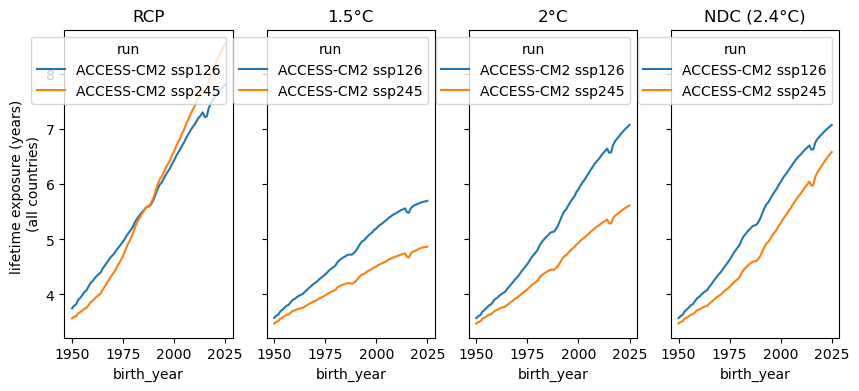

In [47]:
fig, axes = plt.subplots(1,4,sharey=True,figsize=(10,4))

(ds_le_perregion_perrun.sel(region=5)['le_perregion_perrun_RCP'].to_pandas().T /365 ).rename(columns=rename_dict).plot(ax=axes[0])
(ds_le_perregion_perrun.sel(region=5)['le_perregion_perrun_15'].to_pandas().T /365 ).rename(columns=rename_dict).plot(ax=axes[1])
(ds_le_perregion_perrun.sel(region=5)['le_perregion_perrun_20'].to_pandas().T /365 ).rename(columns=rename_dict).plot(ax=axes[2])
(ds_le_perregion_perrun.sel(region=5)['le_perregion_perrun_NDC'].to_pandas().T /365 ).rename(columns=rename_dict).plot(ax=axes[3])

labels = ['RCP', '1.5°C', '2°C',  'NDC (2.4°C)',]

for i,ax in enumerate(axes):
    ax.set_title(labels[i])

axes[0].set_ylabel(f'lifetime exposure (years) \n(all countries)');


# TODO: run for all simulations and see! 

## 5) aggregation function

Median, mean and spread across 'runs' i.e. across remapped / synthetic trajectories

In [57]:
#  area-weighted average (i.e. land fraction exposed if binary)


ds_lfe_perregion_mmm = calc_landfraction_exposed_mmm(
    ds_lfe_perregion_perrun,
    GMT_extra_trajectories_names,
    )



Computing the MMM and stats for each region


In [58]:
# lifetime exposure 

ds_le_perregion_mmm = calc_lifetime_exposure_mmm(
    ds_le_perregion_perrun,
    GMT_extra_trajectories_names,
    year_ref=1950
    )


Computing the MMM and stats for each region


In [59]:

ds_lfe_percountry_mmm = calc_landfraction_exposed_mmm(
    ds_lfe_percountry_perrun,
    GMT_extra_trajectories_names,
    )


Computing the MMM and stats for each country


In [60]:
ds_le_percountry_mmm = calc_lifetime_exposure_mmm(
    ds_le_percountry_perrun,
    GMT_extra_trajectories_names,
    year_ref=1950
    )


Computing the MMM and stats for each country


## 6) Subnational analysis 

In [81]:
# NUTS 3 for only mainland Portugal

dict_keep = {'LEVL_CODE': 3, 'CNTR_CODE': 'PT'}
dict_drop = {'NUTS_ID': ['PT2','PT3']}

gdf_subnat, subnational_regions, subnational_mask = load_subnational_mask(
    filepath_shp = glob.glob(os.path.join(data_dir,'country-masks/shapefiles/eurostat/NUTS_RG_01M_2016/NUTS_RG_*.shp'))[0],
    da_population=da_population,
    bbox=None,
    dict_keep=dict_keep, 
    dict_drop=dict_drop,
    col_name="NUTS_NAME",
    col_id= "NUTS_ID",
    col_country='CNTR_CODE',
    )


load_subnational_mask took 3.12 s


In [86]:
ds_le_perregion_perrun_sn, region_names_sn = calc_lifetime_exposure_subnational(
            subset,
            df_countries,
            subnational_regions,
            subnational_mask,
            gdf_subnat,
            climatedata_dir,
            da_population,
            df_life_expectancy_5,
            da_cohort_size,
            GMT_labels = df_GMT_strj.columns , 
            GMT_extra_trajectories_names=GMT_extra_trajectories_names,
            start_birthyear=1950,
            end_birthyear=2025,
            year_start=1950,
            year_end=2119,
            bbox=None,
            smoothing_window=21,
            )

                         🟠 Remapping Simulation 1 of 2 🟠

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/historical/ACCESS-CM2/FWI_ACCESS-CM2_1950_2014_FWI95d.nc
Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI/ssp126/ACCESS-CM2/FWI_ACCESS-CM2_2015_2100_FWI95d.nc
load_climate_data_array took 0.12 s
⏳ Computing the Population-Weighted Spatial Average of the Exposure for all regions

🟢 Population-Weighted Spatial Average of the Exposure for all regions computed
Computing lifetime exposure (LE) for RCP 

Computing lifetime exposure (LE) for 15 

Computing lifetime exposure (LE) for 20 

Computing lifetime exposure (LE) for NDC 

Computing lifetime exposure (LE) for OS 

Computing lifetime exposure (LE) for noOS 

Computing lifetime exposure (LE) for strj 

                         🟠 Remapping Simulation 2 of 2 🟠

Loading /vscmnt/brussel_pixiu_data/_data_brussel/vo/000/

In [ ]:
# multi model mean

ds_le_perregion_perrun_sn_mmm = calc_lifetime_exposure_mmm(
    ds_le_perregion_perrun_sn,
    GMT_extra_trajectories_names,
    year_ref=1950
    )


Computing the MMM and stats for each region


## 7) Plots

In [62]:
region_names

# Note that World = all countries/area included in your bounding box 

array(['Europe & Central Asia', 'Middle East & North Africa',
       'Upper middle income', 'High income', 'Lower middle income',
       'World'], dtype=object)

Text(0.5, 1.0, 'All countries')

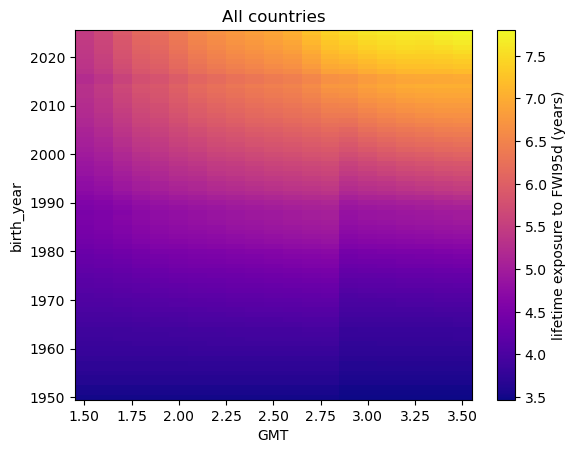

In [63]:
# plot heatmap from median of remapped trajectories (units:years exposed)

(ds_le_perregion_mmm['median_strj']/365).sel(region=5).plot(
    cbar_kwargs={'label': 'lifetime exposure to FWI95d (years)'},
    cmap='plasma'
    )

plt.title('All countries')


Text(0.5, 1.0, 'All countries')

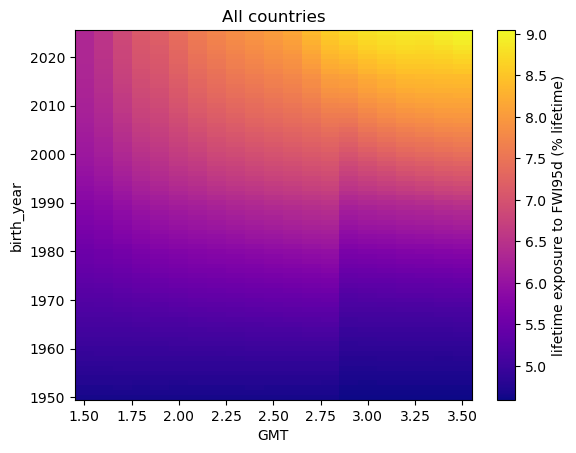

In [64]:
# plot % lifetime exposed 

(((ds_le_perregion_mmm['median_strj']/365) / da_life_expectancy_perregion)*100).sel(region=5).plot(
    cbar_kwargs={'label': 'lifetime exposure to FWI95d (% lifetime)'},
    cmap='plasma'
    )

plt.title('All countries')



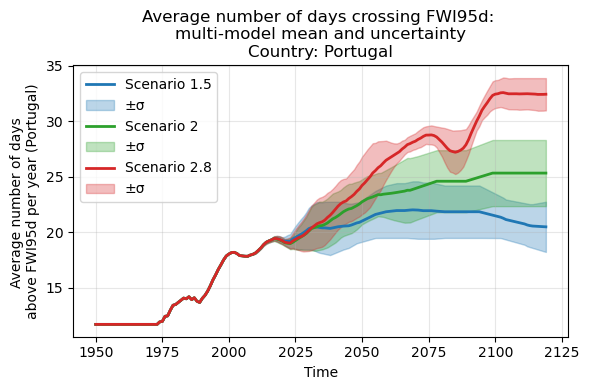

In [ ]:
# timeseries area-weighted average


# === Parameters ===
country_name = 'Portugal'  # <-- change the country here
year_range = np.arange(1950, 1950+len(ds_lfe_percountry_mmm.time_ind))  # x-axis: birth years

# === Define the scenarios to plot ===
GMTs = 1.5, 2, 2.8
colors = {0: 'tab:blue', 1: 'tab:green', 2: 'tab:red'}

# === Create the figure ===
plt.figure(figsize=(6,4))

for i,scen in enumerate(GMTs):
    # Extract multi-model mean and standard deviation for this scenario
    mmm = ds_lfe_percountry_mmm[f'mmm_strj'].sel(country=country_name, GMT=scen).rolling(time_ind=10,min_periods=1).mean() # this is mmm_strj smoothed with .rolling(time_ind=10, center=True, min_periods=1).mean()
    std = ds_lfe_percountry_mmm[f'std_strj'].sel(country=country_name, GMT=scen).rolling(time_ind=10,min_periods=1).mean()
    
    # Plot the mean
    plt.plot(
        year_range, 
        mmm, 
        label=f'Scenario {scen}', 
        color=colors[i],
        lw=2
    )
    
    # Plot the uncertainty range (±σ/2)
    plt.fill_between(
        year_range,
        mmm - std,
        mmm + std ,
        alpha=0.3,
        label=rf'±σ',
        color=colors[i],
        lw=1
    )

# === Customize the plot ===
plt.title(f"Average number of days crossing FWI95d: \nmulti-model mean and uncertainty\nCountry: {country_name}")
plt.xlabel("Time")
plt.ylabel("Average number of days \nabove FWI95d per year (Portugal)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



1.067471553593439 4.394861949997944
1.476976530257147 7.323555158550469
1.6355886537918134 10.027295092231176


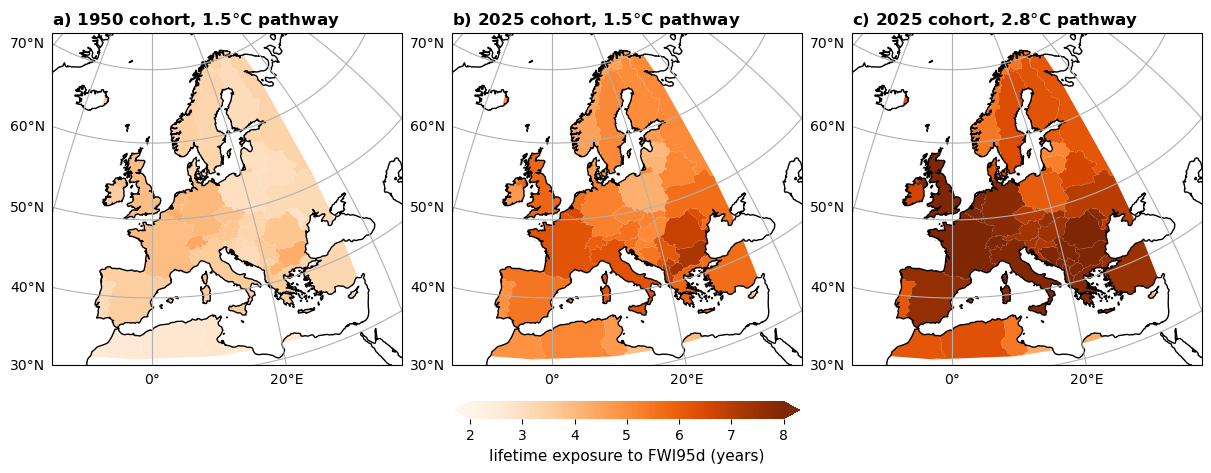

In [ ]:
# map : Europe, country level results



# -------------------- Parameters -------------------- #
GMTs = [1.5, 1.5, 2.8]
birth_years = [1950,2025,2025]
titles = ['a)', 'b)', 'c)']

use_log_scale = False

vmin=2
vmax=8

cmap = plt.cm.Oranges # or OrRd

# -------------------- Projections ---------- #

central_lon, central_lat = 0, 45
extent = [-15, 40, 30, 72]

proj = ccrs.Orthographic(central_lon, central_lat)

# -------------------- Plot -------------------- #

fig, axes = plt.subplots(1,3, figsize=(12,8),subplot_kw={'projection': proj},  layout='constrained')


for ax, birth_year, GMT, title in zip(axes.flatten(), birth_years, GMTs, titles):


    # -------------------- Extract values from ds_le_percountry -------------------- #
    # Multi-model mean for the selected scenario
    le_mean = ds_le_percountry_mmm[f'mmm_strj'].sel(birth_year=birth_year, GMT=GMT) / 365 # for % lfietime  / da_life_expectancy * 100

    # Convert to DataFrame
    df_values = le_mean.to_dataframe(name='mean_val').reset_index()

    # -------------------- Merge with country borders -------------------- #
    gdf_plot = gdf_country_borders.reset_index().merge(
        df_values, left_on='name', right_on='country', how='left'
    )

    gdf_plot.to_crs(proj).plot(
    ax=ax,
    column='mean_val',
    cmap=cmap,
    legend=False,
    legend_kwds={'shrink': 0.5},
    missing_kwds={'color': 'lightgrey'},
    vmin=vmin,vmax=vmax
    )

    ax.set_title(title+f' {birth_year} cohort, {GMT}$\degree$C pathway', loc='left', fontweight='bold')
    ax.set_extent(extent)
    gl = ax.gridlines( draw_labels=True,)
    gl.top_labels = False
    gl.right_labels = False
    ax.coastlines(resolution='50m')

    print(gdf_plot['mean_val'].min(), gdf_plot['mean_val'].max())

# colorbar 
foo = ax.collections[0]
cbar_lab = 'lifetime exposure to FWI95d (years)'
cbar = fig.colorbar(foo, extend='both', ax=axes[0:3], location='bottom',shrink=0.3, fraction=0.08, pad=0.02)
cbar.set_label(label=cbar_lab,size=11)
cbar.outline.set_edgecolor('none')


3.3319563964383327 4.87130097038793
4.001278427561945 6.400208121111771
4.014617685086963 7.052670807365474
3.325136077119342 4.862309431473118
3.975850318627074 6.8331282206555395
4.0161937322843375 8.296082046212554
3.3279869494196346 4.863336385058281
4.0852670474200945 7.47289676858604
4.41962305931891 10.152909615303324


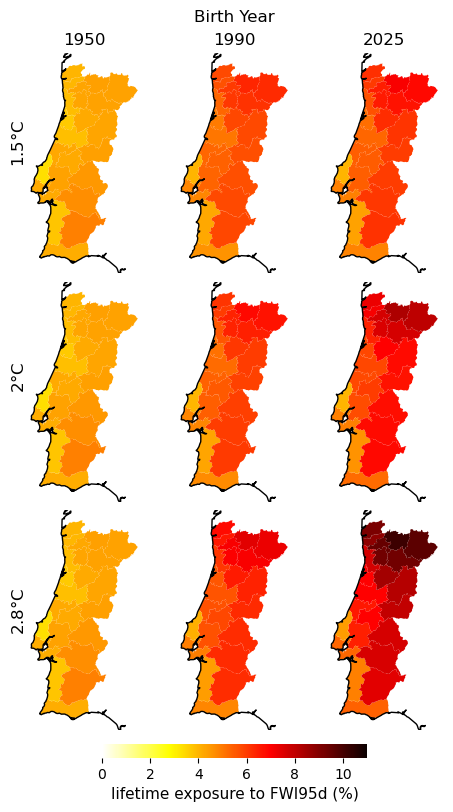

In [92]:
# subnational map 


# -------------------- Parameters -------------------- #
GMTs = [1.5, 2, 2.8]

birth_years = [1950,1990,2025]

GMTs_rep = np.repeat(GMTs,len(birth_years))

birth_years_rep = birth_years*len(GMTs)


vmin=0
vmax=11

cmap = plt.cm.hot_r # or OrRd

# -------------------- Projections ---------- #

central_lon, central_lat = 0, 45
extent = [-15, 40, 30, 72]

proj = ccrs.Orthographic(central_lon, central_lat)

# -------------------- Plot -------------------- #

fig, axes = plt.subplots(len(GMTs),len(birth_years), figsize=(1.5*len(birth_years),8),subplot_kw={'projection': proj},  layout='constrained')


for i, (ax, birth_year, GMT) in enumerate(zip(axes.flatten(), birth_years_rep, GMTs_rep)):


    # -------------------- Extract values from ds_le_percountry -------------------- #
    # Multi-model mean for the selected scenario
    le_mean = (ds_le_perregion_perrun_sn_mmm[f'mmm_strj'].sel(birth_year=birth_year, GMT=GMT) / 3.65 ) / da_life_expectancy.sel(country='Portugal',birth_year=birth_year)
    # Confidence interval (± std/2)
    le_std = (ds_le_perregion_perrun_sn_mmm[f'std_strj'].sel(birth_year=birth_year,  GMT=GMT) / 3.65) / da_life_expectancy.sel(country='Portugal',birth_year=birth_year)
    # Convert to DataFrame
    df_values = le_mean.to_dataframe(name='mean_val').reset_index()

    # -------------------- Merge with country borders -------------------- #
    gdf_plot = gdf_subnat.reset_index().merge(
        df_values, left_on='id', right_on='region', how='left'
    )

    gdf_plot.to_crs(proj).plot(
    ax=ax,
    column='mean_val',
    cmap=cmap,
    legend=False,
    legend_kwds={'shrink': 0.5},
    missing_kwds={'color': 'lightgrey'},
    vmin=vmin,vmax=vmax
    )

    #ax.set_title(f' {birth_year} cohort, {GMT}$\degree$C pathway', loc='left', fontweight='bold')

        # birthyear labels 
    if i < len(birth_years):
        ax.set_title(birth_year, fontsize=12)
    else:
        ax.set_title('')


    ax.coastlines(resolution='10m')

    print(gdf_plot['mean_val'].min(), gdf_plot['mean_val'].max())

for ax in axes.flat:  # or axes.ravel()
    for spine in ax.spines.values():
        spine.set_visible(False)

# colorbar 
foo = ax.collections[0]
cbar_lab = 'lifetime exposure to FWI95d (%)'
cbar = fig.colorbar(foo, extend=None, ax=axes[0:3], location='bottom',shrink=0.6, fraction=0.08, pad=0.02)
cbar.set_label(label=cbar_lab,size=11)
cbar.outline.set_edgecolor('none')

fig.suptitle('Birth Year')

for i, row in enumerate(axes):
    row_axes = row
    # Get their bounding boxes in figure coordinates
    bboxes = [ax.get_position() for ax in row_axes]

    # Compute row midpoint in figure coordinates
    ymin = min(bb.y0 for bb in bboxes)
    ymax = max(bb.y1 for bb in bboxes)
    ymid = (ymin + ymax) / 2

    # Add a label
    fig.text(
        0.02, ymid, f"{GMTs[i]}$\degree$C",
        rotation="vertical", ha="center", va="center",
        fontsize=12
    )


